In [ ]:
!pip install torch torchvision transformers pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import torch
import torchvision
import PIL
import transformers

print(torch.__version__)
print(torchvision.__version__)
print(PIL.__version__)
print(transformers.__version__)


2.6.0+cu124
0.21.0+cu124
11.2.1
4.53.1


In [ ]:
# Установим gdown для скачивания с Google Drive
!pip install --upgrade --no-cache-dir gdown

import gdown

# Ссылка на архив UTKFace на Google Drive
google_path = 'https://drive.google.com/uc?id='
file_id = '16uEk67PncGCl0GxBRfa0iXfobODcs4tu'  # это оригинальный архив UTKFace (~1.3GB)
output_name = 'UTKFace.zip'

# Скачиваем архив
gdown.download(google_path + file_id, output_name, quiet=False)

# Распаковываем архив
import zipfile
with zipfile.ZipFile(output_name, 'r') as zip_ref:
    zip_ref.extractall('UTKFace')

# Проверим содержимое папки
import os
print("Примеры файлов в UTKFace:", os.listdir('UTKFace')[:5])



Downloading...
From (original): https://drive.google.com/uc?id=16uEk67PncGCl0GxBRfa0iXfobODcs4tu
From (redirected): https://drive.google.com/uc?id=16uEk67PncGCl0GxBRfa0iXfobODcs4tu&confirm=t&uuid=1e988130-1861-46ff-a8dc-b1dc13748ba6
To: /content/UTKFace.zip
100%|██████████| 1.40G/1.40G [00:23<00:00, 58.3MB/s]


Примеры файлов в UTKFace: ['test', 'train']


In [ ]:
import os

print("Содержимое папки UTKFace:", os.listdir('UTKFace'))
print("Примеры файлов в train:", os.listdir('UTKFace/train')[:5])
print("Примеры файлов в test:", os.listdir('UTKFace/test')[:5])


Содержимое папки UTKFace: ['test', 'train']
Примеры файлов в train: ['52_1_0_20170109220548552.jpg', '1_1_2_20161219141703736.jpg', '23_1_2_20170116172852744.jpg', '56_0_0_20170113182756438.jpg', '26_1_4_20161221200012536.jpg']
Примеры файлов в test: ['29_0_3_20170119165447462.jpg', '34_0_3_20170119152328504.jpg', '72_1_0_20170120224942952.jpg', '26_1_3_20170119180813956.jpg', '27_0_3_20170119193159666.jpg']


In [ ]:
import os

def get_image_paths_and_labels(folder):
    images = []
    labels = []
    for fname in os.listdir(folder):
        if fname.endswith('.jpg'):
            gender = int(fname.split('_')[1])  # 0 - male, 1 - female
            img_path = os.path.join(folder, fname)
            images.append(img_path)
            labels.append(gender)
    return images, labels

train_dir = 'UTKFace/train'
test_dir = 'UTKFace/test'

train_imgs, train_labels = get_image_paths_and_labels(train_dir)
val_imgs, val_labels = get_image_paths_and_labels(test_dir)

print(f'Пример train: {train_imgs[0]}, label: {train_labels[0]}')
print(f'Пример val: {val_imgs[0]}, label: {val_labels[0]}')


Пример train: UTKFace/train/52_1_0_20170109220548552.jpg, label: 1
Пример val: UTKFace/test/29_0_3_20170119165447462.jpg, label: 0


In [ ]:
# 1. Импорт библиотек и загрузка модели CLIP
from transformers import CLIPProcessor, CLIPModel
import torch
from PIL import Image
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

def get_clip_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt")
    with torch.no_grad():
        image_features = clip_model.get_image_features(**{k: v.to(device) for k, v in inputs.items()})
    return image_features.cpu().numpy().flatten()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
import numpy as np

# Используем все изображения и метки
X_train = np.array([get_clip_embedding(img) for img in train_imgs])
y_train = np.array(train_labels)

X_val = np.array([get_clip_embedding(img) for img in val_imgs])
y_val = np.array(val_labels)


In [ ]:
from sklearn.svm import SVC

# Создаем классификатор SVM с линейным ядром (подойдет для эмбеддингов CLIP)
clf = SVC(kernel='linear', random_state=42, probability=True)

# Обучаем классификатор на тренировочных данных
clf.fit(X_train, y_train)

# Оцениваем точность на валидационной выборке
val_acc = clf.score(X_val, y_val)
print(f"Validation accuracy: {val_acc:.4f}")


Validation accuracy: 0.9846


In [ ]:
idx = 0  # номер изображения в валидационной выборке
img_path = val_imgs[idx]
true_label = val_labels[idx]

embedding = get_clip_embedding(img_path).reshape(1, -1)
pred_label = clf.predict(embedding)[0]

print(f"Файл: {img_path}")
print(f"Истинная метка: {true_label} (0 - male, 1 - female)")
print(f"Предсказание модели: {pred_label} (0 - male, 1 - female)")


Файл: UTKFace/test/29_0_3_20170119165447462.jpg
Истинная метка: 0 (0 - male, 1 - female)
Предсказание модели: 0 (0 - male, 1 - female)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = clf.predict(X_val)
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred, target_names=["male", "female"]))


[[2218   36]
 [  14  982]]
              precision    recall  f1-score   support

        male       0.99      0.98      0.99      2254
      female       0.96      0.99      0.98       996

    accuracy                           0.98      3250
   macro avg       0.98      0.98      0.98      3250
weighted avg       0.98      0.98      0.98      3250



In [ ]:
# Путь к новому изображению
new_img_path = '224903506_2835ff96acc6999eaa997fe29f9489cb_800.jpg'

# Получаем эмбеддинг
new_embedding = get_clip_embedding(new_img_path).reshape(1, -1)

# Получаем предсказание
pred_label = clf.predict(new_embedding)[0]

# Выводим результат
print(f"Предсказание модели: {pred_label} (0 - male, 1 - female)")


Предсказание модели: 1 (0 - male, 1 - female)


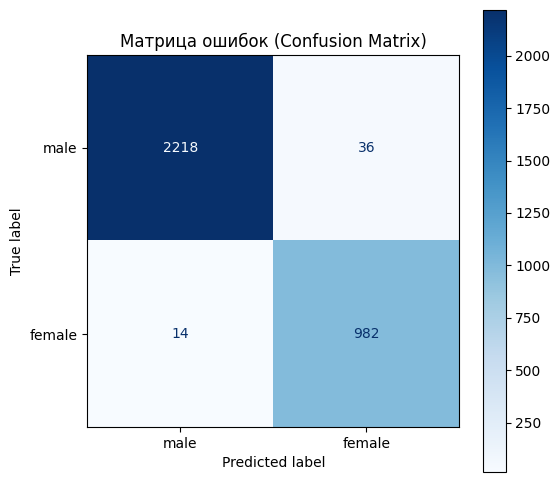

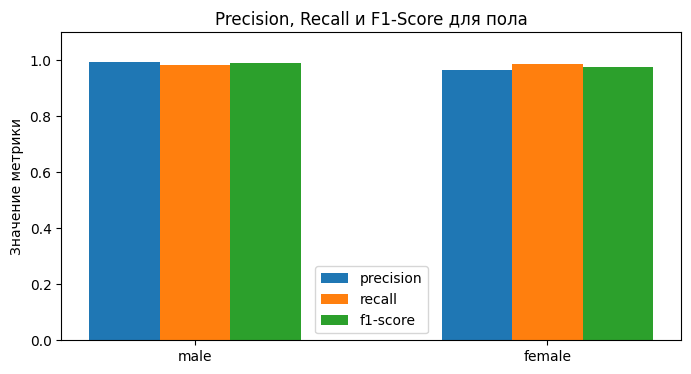

Текстовый отчет по классификации:

              precision    recall  f1-score   support

        male       0.99      0.98      0.99      2254
      female       0.96      0.99      0.98       996

    accuracy                           0.98      3250
   macro avg       0.98      0.98      0.98      3250
weighted avg       0.98      0.98      0.98      3250



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Предсказания на валидационном наборе
y_pred = clf.predict(X_val)

# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["male", "female"])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Матрица ошибок (Confusion Matrix)")
plt.show()

# Отчет по основным метрикам
report = classification_report(y_val, y_pred, target_names=["male", "female"], output_dict=True)

# Отобразим precision, recall и f1-score для каждого класса
labels = ["male", "female"]
metrics_names = ["precision", "recall", "f1-score"]

fig, ax = plt.subplots(figsize=(8,4))
bar_width = 0.2
index = np.arange(len(labels))

for i, metric in enumerate(metrics_names):
    scores = [report[label][metric] for label in labels]
    ax.bar(index + i*bar_width, scores, bar_width, label=metric)

ax.set_xticks(index + bar_width)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Значение метрики")
ax.set_title("Precision, Recall и F1-Score для пола")
ax.legend()

plt.show()

# Выводим текстовый отчет в консоли
print("Текстовый отчет по классификации:\n")
print(classification_report(y_val, y_pred, target_names=["male", "female"]))
